**Objective**

Build a treatment-aware T-Learner using separate logistic regression models for treatment and control groups. Use the difference between their predicted conversion probabilities to estimate **customer-level uplift**, then evaluate the model by ranking customers into uplift deciles and comparing predicted with observed uplift.

In [1]:
#import libraries
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [2]:
#load the development sample
df = pd.read_csv("../../data/samples/criteo_sample.csv")

print("Rows:", len(df))
print("Columns:", len(df.columns))
print(df.head())

Rows: 139796
Columns: 16
          f0         f1        f2        f3         f4        f5         f6  \
0  21.265452  10.059654  8.214383  4.679882  10.280525  4.115453 -12.641800   
1  25.744310  10.059654  8.214383  4.679882  10.280525  4.115453  -3.282109   
2  12.616365  10.059654  8.813527  4.679882  10.280525  4.115453   0.294443   
3  12.616365  10.059654  8.876285  4.679882  10.280525  4.115453   0.294443   
4  12.616365  10.059654  9.007057  4.679882  10.280525  4.115453   0.294443   

         f7        f8         f9       f10       f11  treatment  conversion  \
0  4.833815  3.971858  13.190056  5.300375 -0.168679          0           0   
1  4.833815  3.971858  13.190056  5.300375 -0.168679          1           0   
2  4.833815  3.906514  13.190056  5.300375 -0.168679          1           0   
3  4.833815  3.895862  13.190056  5.300375 -0.168679          1           0   
4  4.833815  3.890052  13.190056  5.300375 -0.168679          1           0   

   visit  exposure  
0   

In [3]:
#define feature and targetted columns
FEATURES = [
    "f0", "f1", "f2", "f3",
    "f4", "f5", "f6", "f7",
    "f8", "f9", "f10", "f11"
]

TREATMENT_COL = "treatment"
LABEL_COL = "conversion"

In [4]:
#validate the modelling data
print("Treatment counts:")
print(df[TREATMENT_COL].value_counts())

print("\nTreatment proportions:")
print(df[TREATMENT_COL].value_counts(normalize=True))

print("\nConversion counts:")
print(df[LABEL_COL].value_counts())

print("\nConversion proportions:")
print(df[LABEL_COL].value_counts(normalize=True))

print("\nMissing values:")
print(df[FEATURES + [TREATMENT_COL, LABEL_COL]].isna().sum())

Treatment counts:
treatment
1    118748
0     21048
Name: count, dtype: int64

Treatment proportions:
treatment
1    0.849438
0    0.150562
Name: proportion, dtype: float64

Conversion counts:
conversion
0    139359
1       437
Name: count, dtype: int64

Conversion proportions:
conversion
0    0.996874
1    0.003126
Name: proportion, dtype: float64

Missing values:
f0            0
f1            0
f2            0
f3            0
f4            0
f5            0
f6            0
f7            0
f8            0
f9            0
f10           0
f11           0
treatment     0
conversion    0
dtype: int64


In [5]:
#seperate treatment and control
df_treat = df[df[TREATMENT_COL] == 1].copy()
df_ctrl = df[df[TREATMENT_COL] == 0].copy()

print("Treatment rows:", len(df_treat))
print("Control rows:", len(df_ctrl))

Treatment rows: 118748
Control rows: 21048


In [6]:
#download sample treatment
df_treat_ds = df_treat.sample(
    n=len(df_ctrl),
    random_state=42
)

print("Downsampled treatment rows:", len(df_treat_ds))
print("Control rows:", len(df_ctrl))

Downsampled treatment rows: 21048
Control rows: 21048


In [7]:
#create balanced dataset
df_balanced = (
    pd.concat([df_treat_ds, df_ctrl], axis=0)
    .sample(frac=1, random_state=42)
    .reset_index(drop=True)
)

print("Balanced treatment/control counts:")
print(df_balanced[TREATMENT_COL].value_counts())

print("\nBalanced proportions:")
print(df_balanced[TREATMENT_COL].value_counts(normalize=True))

Balanced treatment/control counts:
treatment
0    21048
1    21048
Name: count, dtype: int64

Balanced proportions:
treatment
0    0.5
1    0.5
Name: proportion, dtype: float64


In [8]:
#create treatment x conversion strata
strata = (
    df_balanced[TREATMENT_COL].astype(str)
    + "_"
    + df_balanced[LABEL_COL].astype(str)
)

print("Stratification groups:")
print(strata.value_counts())

Stratification groups:
0_0    21014
1_0    20983
1_1       65
0_1       34
Name: count, dtype: int64


In [9]:
#create 80/20 train/test split
train_df, test_df = train_test_split(
    df_balanced,
    test_size=0.20,
    stratify=strata,
    random_state=42
)

print("Training rows:", len(train_df))
print("Test rows:", len(test_df))

Training rows: 33676
Test rows: 8420


In [10]:
#validate the train/test split
print("Training treatment distribution:")
print(
    train_df[TREATMENT_COL].value_counts(normalize=True)
)

print("\nTest treatment distribution:")
print(
    test_df[TREATMENT_COL].value_counts(normalize=True)
)

print("\nTraining treatment × conversion:")
print(
    train_df.groupby(
        [TREATMENT_COL, LABEL_COL]
    ).size()
)

print("\nTest treatment × conversion:")
print(
    test_df.groupby(
        [TREATMENT_COL, LABEL_COL]
    ).size()
)

Training treatment distribution:
treatment
1    0.5
0    0.5
Name: proportion, dtype: float64

Test treatment distribution:
treatment
1    0.5
0    0.5
Name: proportion, dtype: float64

Training treatment × conversion:
treatment  conversion
0          0             16811
           1                27
1          0             16786
           1                52
dtype: int64

Test treatment × conversion:
treatment  conversion
0          0             4203
           1                7
1          0             4197
           1               13
dtype: int64


**Train the T-Learner**

The T-Learner consists of two independent machine learning models:

*   **Treatment Model:** 
    Learns the probability of conversion for those who received the offer: $P(Y=1 \mid X, T=1)$
*   **Control Model:** 
    Learns the probability of conversion for those who did not receive the offer: $P(Y=1 \mid X, T=0)$

In [11]:
#seperate training treatment and control
train_t = train_df[
    train_df[TREATMENT_COL] == 1
].copy()

train_c = train_df[
    train_df[TREATMENT_COL] == 0
].copy()

print("Treatment training rows:", len(train_t))
print("Control training rows:", len(train_c))

Treatment training rows: 16838
Control training rows: 16838


In [12]:
# Train treatment model
model_treatment = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_treatment.fit(
    train_t[FEATURES],
    train_t[LABEL_COL]
)

print("Treatment model trained successfully.")

Treatment model trained successfully.


In [13]:
# Train control model
model_control = LogisticRegression(
    max_iter=1000,
    class_weight="balanced"
)

model_control.fit(
    train_c[FEATURES],
    train_c[LABEL_COL]
)

print("Control model trained successfully.")

Control model trained successfully.


In [14]:
# Predict treatment probability
p_treat = model_treatment.predict_proba(
    test_df[FEATURES]
)[:, 1]

print("Treatment predictions generated:", len(p_treat))

Treatment predictions generated: 8420


In [15]:
# Predict control probability
p_ctrl = model_control.predict_proba(
    test_df[FEATURES]
)[:, 1]

print("Control predictions generated:", len(p_ctrl))

Control predictions generated: 8420


In [16]:
# Calculate predicted uplift
test_df = test_df.copy()

test_df["p_treatment"] = p_treat
test_df["p_control"] = p_ctrl

test_df["uplift"] = (
    test_df["p_treatment"]
    - test_df["p_control"]
)

print("Uplift calculated successfully.")

Uplift calculated successfully.


In [17]:
#inspect the predictions
print(
    test_df[
        [
            TREATMENT_COL,
            LABEL_COL,
            "p_treatment",
            "p_control",
            "uplift"
        ]
    ].head(10)
)

#inspect the uplift distribution
print("\nUplift distribution:")
print(test_df["uplift"].describe())

       treatment  conversion  p_treatment  p_control    uplift
23673          1           0     0.052518   0.047223  0.005295
35819          0           0     0.838526   0.180424  0.658103
35433          1           0     0.091703   0.401286 -0.309584
2200           0           0     0.952847   0.960280 -0.007433
35075          1           0     0.247863   0.409223 -0.161360
20237          0           0     0.064960   0.062831  0.002129
5824           0           0     0.030432   0.025081  0.005351
3717           0           0     0.037861   0.048030 -0.010169
5056           1           0     0.999207   0.999770 -0.000562
24461          1           0     0.093641   0.277935 -0.184294

Uplift distribution:
count    8420.000000
mean        0.005847
std         0.137796
min        -0.759514
25%        -0.033332
50%         0.005436
75%         0.045302
max         0.976511
Name: uplift, dtype: float64


In [18]:
#create uplift deciles
test_df["uplift_decile"] = pd.qcut(
    test_df["uplift"],
    q=10,
    labels=False,
    duplicates="drop"
)

print(
    test_df["uplift_decile"].value_counts().sort_index()
)

uplift_decile
0    842
1    842
2    842
3    842
4    842
5    842
6    842
7    842
8    842
9    842
Name: count, dtype: int64


In [19]:
# Calculate observed uplift by decile
decile_results = []

for decile, group in test_df.groupby(
    "uplift_decile",
    observed=True
):

    treatment_group = group[
        group[TREATMENT_COL] == 1
    ]

    control_group = group[
        group[TREATMENT_COL] == 0
    ]

    treatment_rate = treatment_group[LABEL_COL].mean()
    control_rate = control_group[LABEL_COL].mean()

    observed_uplift = (
        treatment_rate - control_rate
    )

    predicted_uplift = group["uplift"].mean()

    decile_results.append({
        "uplift_decile": decile,
        "customers": len(group),
        "treatment_customers": len(treatment_group),
        "control_customers": len(control_group),
        "treatment_conversions": treatment_group[LABEL_COL].sum(),
        "control_conversions": control_group[LABEL_COL].sum(),
        "treatment_conversion_rate": treatment_rate,
        "control_conversion_rate": control_rate,
        "observed_uplift": observed_uplift,
        "predicted_uplift": predicted_uplift
    })

decile_tbl = pd.DataFrame(decile_results)

In [20]:
# Rank deciles from highest to lowest predicted uplift
decile_tbl = (
    decile_tbl
    .sort_values(
        "uplift_decile",
        ascending=False
    )
    .reset_index(drop=True)
)

decile_tbl["rank"] = np.arange(
    1,
    len(decile_tbl) + 1
)

decile_tbl

,uplift_decile,customers,treatment_customers,control_customers,treatment_conversions,control_conversions,treatment_conversion_rate,control_conversion_rate,observed_uplift,predicted_uplift,rank
0,9,842,434,408,0,0,0.000000,0.000000,0.000000,0.276574,1
1,8,842,405,437,0,0,0.000000,0.000000,0.000000,0.092334,2
2,7,842,414,428,0,0,0.000000,0.000000,0.000000,0.046117,3
3,6,842,414,428,1,1,0.002415,0.002336,0.000079,0.022742,4
4,5,842,389,453,3,0,0.007712,0.000000,0.007712,0.009398,5
5,4,842,437,405,3,2,0.006865,0.004938,0.001927,0.001734,6
6,3,842,429,413,0,1,0.000000,0.002421,-0.002421,-0.008825,7
7,2,842,418,424,3,0,0.007177,0.000000,0.007177,-0.035055,8
8,1,842,447,395,0,1,0.000000,0.002532,-0.002532,-0.099199,9
9,0,842,423,419,3,2,0.007092,0.004773,0.002319,-0.247352,10


**Initial Decile Evaluation Summary**

*   **Expected vs. Observed Trends:** The T-Learner successfully produces a smooth **predicted uplift ranking**, with scores properly decreasing from the highest-ranked to the lowest-ranked deciles. However, the **observed (actual) uplift is not monotonic** (it does not decrease smoothly). For instance, Decile 8 shows a positive observed uplift of ~0.0072 despite having a negative predicted uplift, while Decile 1 recorded zero conversions in both groups.
*   **Root Cause (Data Sparsity):** This volatility is a direct mathematical result of the severe class imbalance in the Criteo dataset. With only **437 conversions across 139,796 observations**, each test-set decile contains a microscopic number of actual conversions (often 0–3 per group). Consequently, a single random customer converting can wildly skew the observed uplift for that entire decile.
*   **Conclusion:** The jagged, non-monotonic pattern of observed uplift is a byproduct of the low conversion rate, not necessarily a failure of the T-Learner methodology. These results should be treated as exploratory, keeping the extreme sparsity of the target label in mind.

In [21]:
#test conversion count
print("Test rows:", len(test_df))
print("Test conversions:", test_df[LABEL_COL].sum())
print(
    "Test conversion rate:",
    test_df[LABEL_COL].mean()
)

Test rows: 8420
Test conversions: 20
Test conversion rate: 0.0023752969121140144


In [22]:
#how many actual conversions are available for evaluating the model.
print(
    test_df.groupby(TREATMENT_COL)[LABEL_COL].agg(
        ["count", "sum", "mean"]
    )
)

           count  sum      mean
treatment                      
0           4210    7  0.001663
1           4210   13  0.003088


**Test-Set Conversion Check**

*   **Overall Test Metrics:** The test set contains **8,420 observations** but only **20 actual conversions**, resulting in a baseline conversion rate of just **0.2375%**. 
*   **Treatment vs. Control:** 
    *   **Treatment Group:** 13 conversions out of 4,210 observations (0.3088%)
    *   **Control Group:** 7 conversions out of 4,210 observations (0.1663%)
    *   **Observed Difference:** The campaign generated a modest overall uplift of approximately **0.1425 percentage points**.
*   **The Sparsity Limitation:** Because there are only 20 total conversions to distribute across 10 uplift deciles, several deciles naturally contain zero conversions. This makes the observed uplift estimates at the decile level highly sensitive to individual observations.
*   **Conclusion:** Due to this extremely low event count, the decile-level observed uplift should be interpreted as **exploratory and highly noisy**, rather than as a precise, reliable estimate of incremental treatment effect.

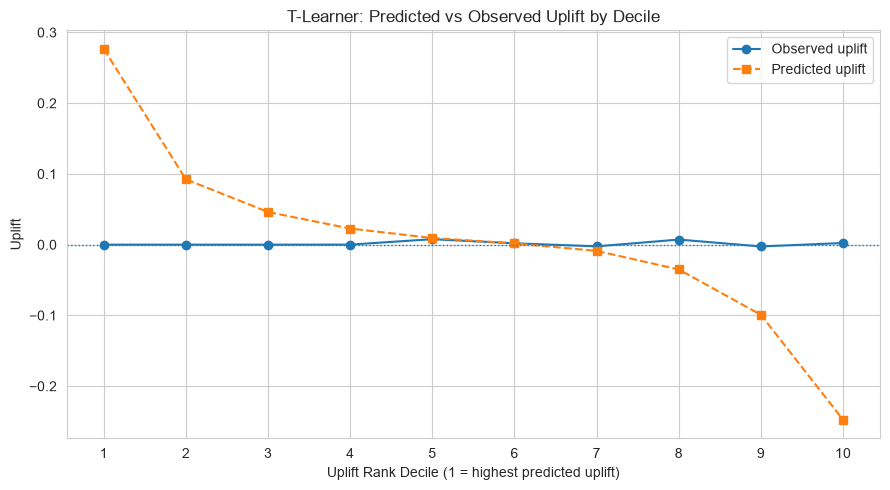

In [23]:
plt.figure(figsize=(9, 5))

plt.plot(
    decile_tbl["rank"],
    decile_tbl["observed_uplift"],
    marker="o",
    label="Observed uplift"
)

plt.plot(
    decile_tbl["rank"],
    decile_tbl["predicted_uplift"],
    marker="s",
    linestyle="--",
    label="Predicted uplift"
)

plt.axhline(
    y=0,
    linestyle=":",
    linewidth=1
)

plt.xlabel(
    "Uplift Rank Decile (1 = highest predicted uplift)"
)

plt.ylabel("Uplift")

plt.title(
    "T-Learner: Predicted vs Observed Uplift by Decile"
)

plt.xticks(range(1, len(decile_tbl) + 1))

plt.legend()

plt.tight_layout()
plt.show()

**Model Reliability and Limitations**

While the T-learner produces a clean monotonic ranking, the predicted uplift magnitudes—ranging from −0.76 to +0.98 with a decile spread of ~0.53—are two to three orders of magnitude larger than the true population average (~0.00115). This extreme scaling is independent of test-set noise and stems directly from the model configuration.

* **Root Cause:** With severe class imbalance (only 52 positive cases in treatment and 27 in control across 12 continuous features) combined with `class_weight="balanced"` and zero regularization, unconstrained logistic regression suffers from quasi-complete separation. The model fits tightly to rare positive examples, generating overconfident, poorly calibrated probabilities.
* **Conclusion:** The current decile ranking reflects confident overfitting rather than true individual treatment effect heterogeneity, making it an untrustworthy estimator.

These structural flaws are addressed in `04_customer_targeting_model_v2.ipynb`, which retrains the T-learner using feature standardization, proper regularization, and without class balancing.